Task 1  (`datasaurus.csv`)

**Name:** Ali Afzal
**Roll No.:** SU92-BSAIM-F23-102
**Subject:** Data Visualization



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")

# House style copied from the Week 1 lecture: colour-blind-safe palette,
# left-aligned titles, no chart box, light grid.
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "legend.frameon": False,
    "lines.linewidth": 2, "font.size": 11,
})


def note(ax, text, y=-0.2):
    # Grey footnote under a chart - used to say which rows were left out.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)

In [4]:
df = pd.read_csv(DATA / "datasaurus.csv")
print(df.shape, "-", df["dataset"].nunique(), "datasets")
print("Missing values:", df.isna().sum().sum())
df.groupby("dataset").size()

(1846, 3) - 13 datasets
Missing values: 0


dataset
away          142
bullseye      142
circle        142
dino          142
dots          142
h_lines       142
high_lines    142
slant_down    142
slant_up      142
star          142
v_lines       142
wide_lines    142
x_shape       142
dtype: int64


Step 1 - The summary table

In [5]:
stats = df.groupby("dataset").agg(
    mean_x=("x", "mean"),
    mean_y=("y", "mean"),
    std_x=("x", "std"),
    std_y=("y", "std"),
)
# Correlation has to be worked out per group, same as in the lecture.
stats["corr_xy"] = df.groupby("dataset").apply(lambda g: g["x"].corr(g["y"]), include_groups=False)
stats.round(2)

,mean_x,mean_y,std_x,std_y,corr_xy
dataset,,,,,
away,54.27,47.83,16.77,26.94,-0.06
bullseye,54.27,47.83,16.77,26.94,-0.07
circle,54.27,47.84,16.76,26.93,-0.07
dino,54.26,47.83,16.77,26.94,-0.06
dots,54.26,47.84,16.77,26.93,-0.06
h_lines,54.26,47.83,16.77,26.94,-0.06
high_lines,54.27,47.84,16.77,26.94,-0.07
slant_down,54.27,47.84,16.77,26.94,-0.07
slant_up,54.27,47.83,16.77,26.94,-0.07


### Step 2 - What would I conclude from the table alone?
If this table was all I had, I'd say the 13 datasets are basically the same data. Every row has the same means (about 54 for x and 48 for y), the same spread, and a correlation of about -0.06. A correlation that close to zero means no real relationship, so I'd picture each one as a random cloud of points. I wouldn't see any reason to plot them separately.
### Step 3 - Plot all 13

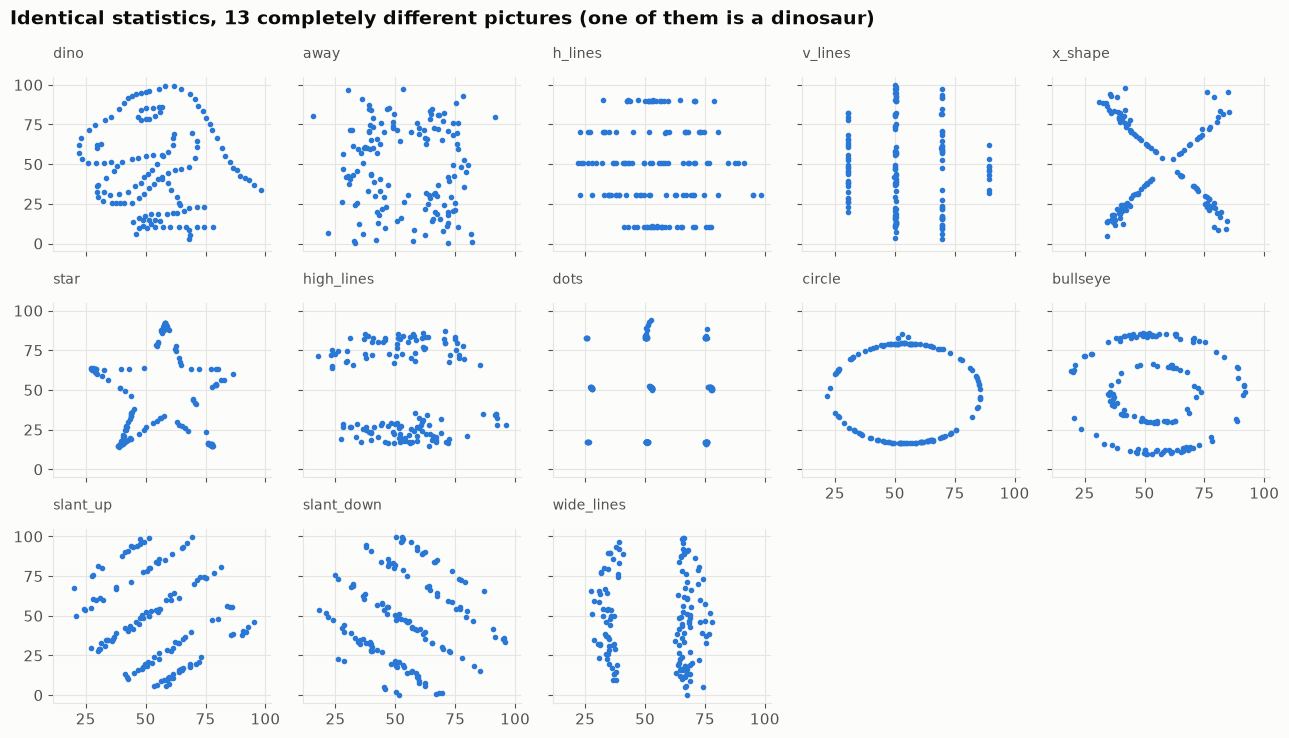

In [6]:
names = df["dataset"].unique()  # keeps the file order, so the dino comes first

fig, axes = plt.subplots(3, 5, figsize=(13, 7.5), sharex=True, sharey=True)
for ax, name in zip(axes.flat, names):
    group = df[df["dataset"] == name]
    ax.scatter(group["x"], group["y"], s=9, color=BLUE)
    ax.set_title(name, fontsize=10, fontweight="normal", color=INK_SOFT)

for ax in axes.flat[len(names):]:
    ax.set_visible(False)
for ax in axes[1, 3:]:
    ax.tick_params(labelbottom=True)  # these panels sit above the two hidden ones

fig.suptitle("Identical statistics, 13 completely different pictures (one of them is a dinosaur)",
             x=0.01, ha="left", fontsize=14, fontweight="bold", color=INK)
fig.tight_layout()
plt.show()

**Why this chart:** each row is a pair of numbers, and I want to see how x and y relate, so a scatter plot is the right choice. I used a grid with shared axes so all 13 panels are on the same scale and easy to compare. One colour is enough, because the panel titles already name each dataset.

### Step 4 - What I actually found

The table suggested 13 copies of the same random cloud. The plots show something completely different: a dinosaur, a star, a circle, a bullseye, an X, straight lines and a grid of dots. Only away looks like the cloud I expected.
The statistics weren't wrong. They only describe the centre, the spread and how well a straight line fits, not the shape. The circle is a good example: the points clearly follow a pattern, but the correlation is near zero because the pattern isn't a straight line.

### The question: do 13 datasets and 142 points make the statistics more trustworthy?

No,

More points make each number more precise, so the mean of 142 points is a better estimate than the mean of 11. But precision was never the problem with Anscombe's quartet. The problem is that a few summary numbers can't describe a shape, and that's true whether you have 11 points or 142.

More points actually make it easier to fool the statistics. These datasets were made on purpose (Matejka and Fitzmaurice, 2017) by slowly moving the dinosaur's points into new shapes while keeping the statistics the same. With 142 points there's plenty of room to do that. And 13 datasets instead of 4 just means more different shapes hiding behind the same numbers.
